In [106]:
import torch
from torch import nn
import numpy
import matplotlib.pyplot as plt
import cv2 as cv
from typing import Tuple

In [208]:
def positional_encoding(image: numpy.typing.NDArray) -> Tuple[torch.Tensor, torch.Tensor]:
    height, width, _ = image.shape
    # create grid of coordinates
    x = torch.linspace(0, 1, width)
    y = torch.linspace(0, 1, height)
    xx, yy =  torch.meshgrid(x, y, indexing='xy')
    # reshape pixel coordinates to shape (num_pixels, 2)
    positions = torch.stack([xx.flatten(), yy.flatten()], dim=-1)
    rgb_values = torch.from_numpy(image).reshape(-1, 3) / 255.
    
    return positions, rgb_values


In [209]:
class ImplicitNeuralRepresentation(nn.Module):
    def __init__(self, hidden_dim=256, n_hidden_layers=8) -> None:
        super().__init__()
        self.layers = [nn.Linear(2, hidden_dim), nn.ReLU()]
        for _ in range(n_hidden_layers - 1):
            self.layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]) # hidden_dim -> hidden_dim
        self.layers.extend(
            [
                nn.Linear(hidden_dim, 3), # hiddem_dim -> RGB value
            ]) 
        self.network = nn.Sequential(*self.layers)
    
    def forward(self, coords):
        return torch.sigmoid(self.network(coords))

In [210]:
image = cv.imread('../benchmark/img/flower.jpg')

In [211]:
image.shape

(1280, 1920, 3)

In [212]:
image_resize = cv.resize(
    image, 
    dsize=(
        image.shape[1]//8,
        image.shape[0]//8)
        )

In [213]:
image_resize.shape

(160, 240, 3)

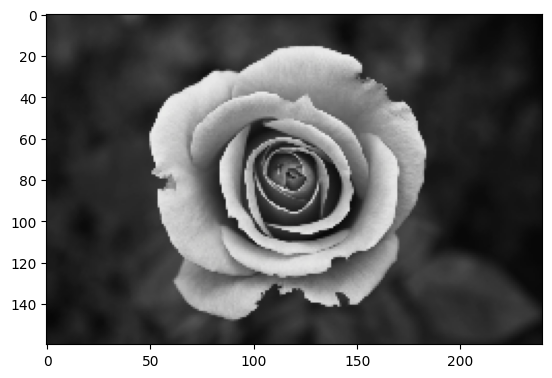

In [214]:
plt.imshow(image_resize)

In [215]:
X, Y = positional_encoding(image_resize)

In [216]:
X.shape

torch.Size([38400, 2])

In [217]:
def train_model(
        x: torch.Tensor,
        y: torch.Tensor,
        model: nn.Module,
        num_epochs: int = 1000,
        learning_rate: float = 1e-3,
        batch_size: int = 4096
) -> nn.Module:
    # move data and model to GPU
    device = torch.device("mps")
    x = x.to(device)
    y = y.to(device)
    model = model.to(device)
    # set up loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # training loop
    for epoch in range(num_epochs):
        total_loss = 0.0
        num_batches = 0
        # create batch indices
        perm = torch.randperm(x.shape[0])

        for i in range(0, x.shape[0], batch_size):
            batch_indices = perm[i:i+batch_size]
            x_batch = x[batch_indices]
            y_batch = y[batch_indices]
            # forward pass
            y_hat = model(x_batch)
            loss = criterion(y_hat, y_batch)
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
        
        # Print epoch statistics
        avg_loss = total_loss / num_batches
        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    print("Training completed!")
    return model

In [218]:
model = ImplicitNeuralRepresentation()

In [250]:
4096/2

2048.0

In [251]:
trained_model = train_model(x=X, y=Y, model=model, batch_size=2048)

Epoch [100/1000], Loss: 0.0025
Epoch [200/1000], Loss: 0.0034
Epoch [300/1000], Loss: 0.0022
Epoch [400/1000], Loss: 0.0020
Epoch [500/1000], Loss: 0.0018
Epoch [600/1000], Loss: 0.0015
Epoch [700/1000], Loss: 0.0014
Epoch [800/1000], Loss: 0.0012
Epoch [900/1000], Loss: 0.0016
Epoch [1000/1000], Loss: 0.0011
Training completed!


In [252]:
prediction = trained_model.forward(X.to("mps"))

In [253]:
image_prediction = prediction.reshape(image_resize.shape).cpu()

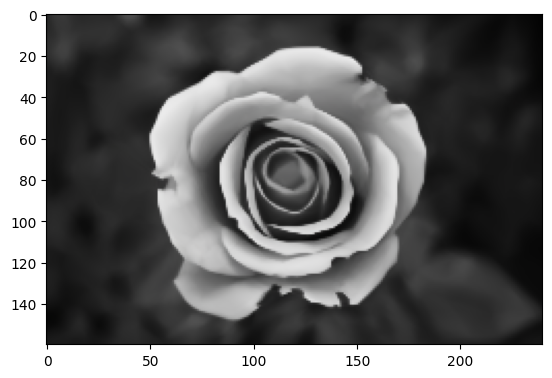

In [254]:
plt.imshow(image_prediction.detach())

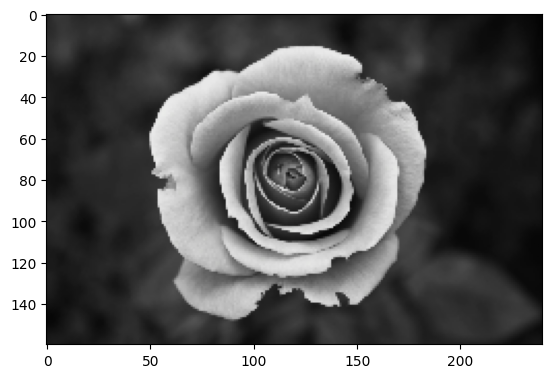

In [151]:
plt.imshow(Y.reshape(image_resize.shape))

In [241]:
xx_xy, yy_xy = torch.meshgrid(
    torch.linspace(0, 1, image_resize.shape[1]*4),
    torch.linspace(0, 1, image_resize.shape[0]*4),
    indexing='xy'
)

In [242]:
X_xy = torch.stack([xx_xy.flatten(), yy_xy.flatten()], dim=-1)

In [243]:
X_xy.size()

torch.Size([614400, 2])

In [244]:
Y_xy = model.forward(X_xy.to("mps"))

In [247]:
image_resize.shape

(160, 240, 3)

In [248]:
image_xy = Y_xy.reshape(image_resize.shape[0]*4, image_resize.shape[1]*4, 3).cpu().detach()

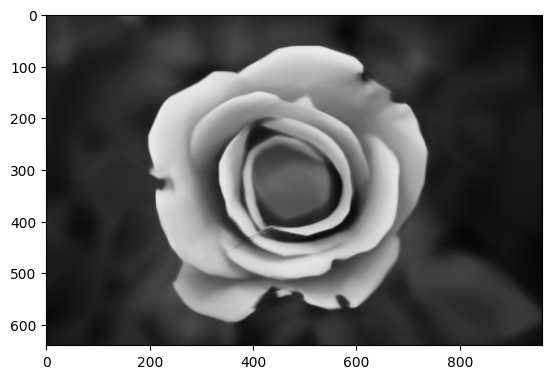

In [249]:
plt.imshow(image_xy,)